# Visualisasi Proses QIM Watermarking
Notebook ini memecah dan memvisualisasikan setiap tahapan yang terjadi di dalam `QIM_embed.py`.
Langkah-langkah ini meliputi: 
1. Konversi Warna & Subsampling
2. Transformasi DCT pada Blok 8x8
3. Proses Quantization Index Modulation (QIM)
4. Rekonstruksi Citra
5. Ekstraksi Watermark

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct, idct
from QIM_embed import scale_qtable, LUMA_BASE

# Setup plot ukuran default
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Membaca Citra Host dan Watermark

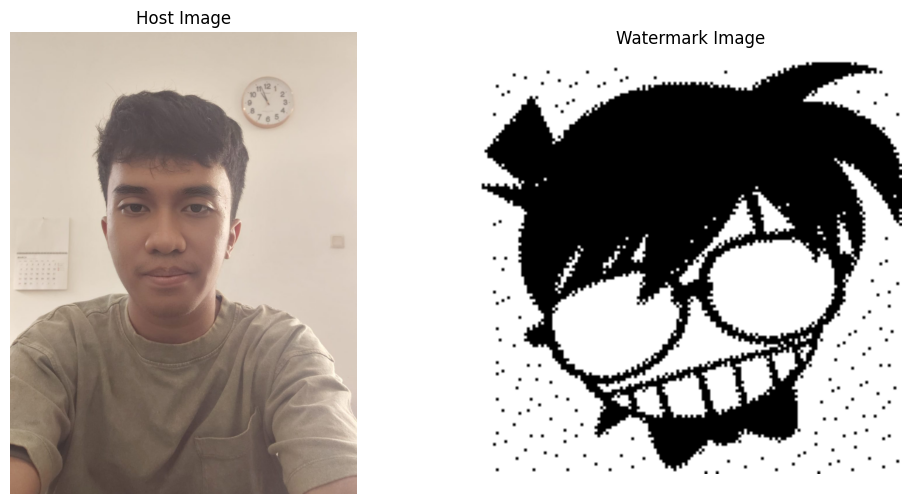

In [ ]:
# Load Host Image
host_img = Image.open('input_self.jpg').convert('RGB')
host_arr = np.array(host_img)

# Load Watermark
wm_img = Image.open('wm_rev.jpg').convert('1')
wm_arr = np.array(wm_img, dtype=bool)
wm_flat = wm_arr.flatten()

fig, axes = plt.subplots(1, 2)
axes[0].imshow(host_arr)
axes[0].set_title('Host Image')
axes[0].axis('off')
axes[1].imshow(wm_arr, cmap='gray')
axes[1].set_title('Watermark Image')
axes[1].axis('off')
plt.show()

## 2. Konversi Warna ke YCbCr dan Ekstraksi Kanal Y (Luminance)

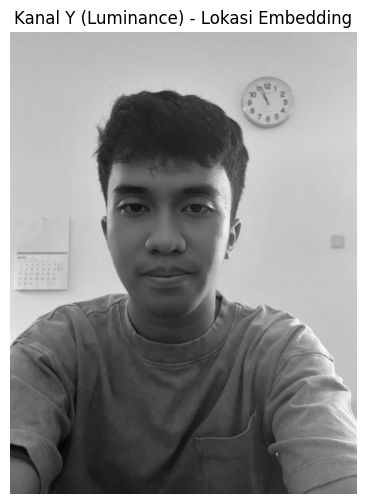

In [ ]:
# Ubah RGB ke YCbCr menggunakan OpenCV
ycbcr = cv2.cvtColor(host_arr, cv2.COLOR_RGB2YCrCb)
Y, Cr, Cb = cv2.split(ycbcr)

plt.imshow(Y, cmap='gray')
plt.title('Kanal Y (Luminance) - Lokasi Embedding')
plt.axis('off')
plt.show()

## 3. Proses DCT, Quantization, dan QIM Embedding pada Blok Pertama
Mari kita lihat apa yang terjadi pada blok 8x8 pertama saat kita menyisipkan bit.

In [ ]:
# Definisikan helper function DCT
def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

qf = 90
delta_factor = 2
qtable = scale_qtable(LUMA_BASE, qf)

# Ambil blok 8x8 pertama (kiri atas)
block = Y[0:8, 0:8].astype(np.float32) - 128.0
dct_block = dct2(block)

# Kuantisasi Blok
quantized_block = np.round(dct_block / qtable)

print("Koefisien Quantized DCT Asli:\n", quantized_block)

Koefisien Quantized DCT Asli:
 [[181.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]]


In [ ]:
# Embedding bit pertama dari watermark pada koordinat (2,2)
bit = wm_flat[0]
q_val = quantized_block[2, 2]
step = delta_factor

# Modulasi QIM
if bit:
    # Ganjil
    embedded_val = np.round((q_val - step/2) / step) * step + step/2
else:
    # Genap
    embedded_val = np.round(q_val / step) * step

quantized_block_embedded = quantized_block.copy()
quantized_block_embedded[2, 2] = embedded_val

print(f"Menyisipkan Bit: {int(bit)}")
print(f"Nilai sebelum di-embed (2,2): {q_val}")
print(f"Nilai setelah di-embed (2,2): {embedded_val}")
print("\nKoefisien Quantized DCT Sesudah Embed:\n", quantized_block_embedded)

Menyisipkan Bit: 1
Nilai sebelum di-embed (2,2): 0.0
Nilai setelah di-embed (2,2): 1.0

Koefisien Quantized DCT Sesudah Embed:
 [[181.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   1.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]]


## 4. Ekstraksi Bit dari Koefisien DCT

In [ ]:
# Ekstraksi dilakukan dengan membagi nilai terkuantisasi dengan step
# dan mengecek apakah ia ganjil atau genap
q_recovered = quantized_block_embedded[2, 2]
extracted_bit = int(np.round(q_recovered / (step / 2))) % 2

print(f"Nilai yang diekstrak: {q_recovered}")
print(f"Bit hasil ekstraksi : {extracted_bit}")
print(f"Sama dengan bit asli? {extracted_bit == int(bit)}")

Nilai yang diekstrak: 1.0
Bit hasil ekstraksi : 1
Sama dengan bit asli? True


## 5. Rekonstruksi dan Perbandingan Visual Blok

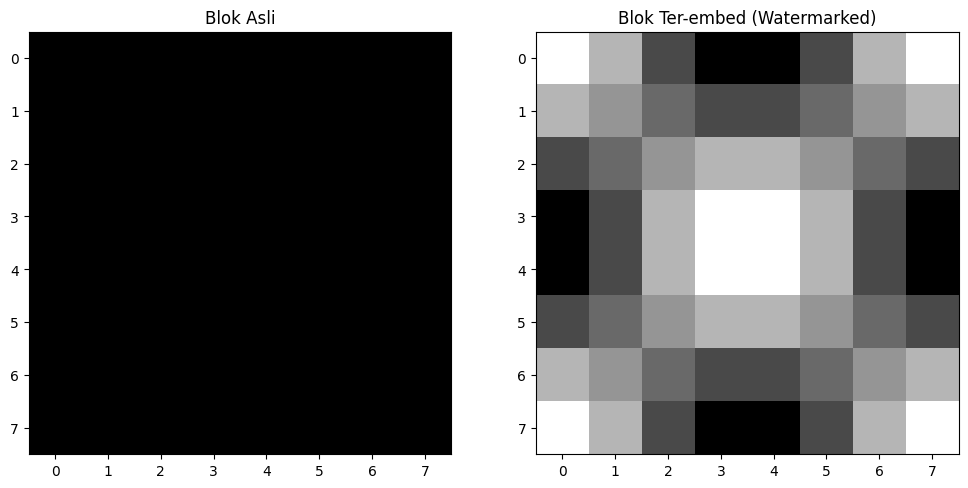

Perbedaan piksel sangat minim sehingga tidak terlihat oleh mata manusia.


In [ ]:
# Inverse Quantization & Inverse DCT
idct_block_ori = idct2(quantized_block * qtable) + 128.0
idct_block_emb = idct2(quantized_block_embedded * qtable) + 128.0

fig, axes = plt.subplots(1, 2)
axes[0].imshow(idct_block_ori, cmap='gray')
axes[0].set_title('Blok Asli')
axes[1].imshow(idct_block_emb, cmap='gray')
axes[1].set_title('Blok Ter-embed (Watermarked)')
plt.show()

print("Perbedaan piksel sangat minim sehingga tidak terlihat oleh mata manusia.")